In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train = pd.read_csv("/content/drive/MyDrive/ml_dataset/train.csv")
meal = pd.read_csv("/content/drive/MyDrive/ml_dataset/meal_info.csv")
center = pd.read_csv("/content/drive/MyDrive/ml_dataset/fulfilment_center_info.csv")

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ml_dataset/train.csv")
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ml_dataset/meal_info.csv")
df.head()

,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ml_dataset/fulfilment_center_info.csv")
df.head()

,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   center_id    77 non-null     int64  
 1   city_code    77 non-null     int64  
 2   region_code  77 non-null     int64  
 3   center_type  77 non-null     object 
 4   op_area      77 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 3.1+ KB


In [ ]:
df.head()

,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6


In [ ]:
print(df)

    center_id  city_code  region_code center_type  op_area
0          11        679           56      TYPE_A      3.7
1          13        590           56      TYPE_B      6.7
2         124        590           56      TYPE_C      4.0
3          66        648           34      TYPE_A      4.1
4          94        632           34      TYPE_C      3.6
..        ...        ...          ...         ...      ...
72         53        590           56      TYPE_A      3.8
73         30        604           56      TYPE_A      3.5
74         76        614           85      TYPE_A      3.0
75         68        676           34      TYPE_B      4.1
76         51        638           56      TYPE_A      7.0

[77 rows x 5 columns]


In [ ]:
df.shape

(77, 5)

In [ ]:
df.describe()

,center_id,city_code,region_code,op_area
count,77.000000,77.000000,77.000000,77.000000
mean,83.142857,600.662338,56.493506,3.985714
std,46.090219,66.720274,18.126473,1.106406
min,10.000000,456.000000,23.000000,0.900000
25%,50.000000,553.000000,34.000000,3.500000
50%,77.000000,596.000000,56.000000,3.900000
75%,110.000000,651.000000,77.000000,4.400000
max,186.000000,713.000000,93.000000,7.000000


In [ ]:
df.columns

Index(['center_id', 'city_code', 'region_code', 'center_type', 'op_area'], dtype='object')

In [ ]:
#Data Cleaning: Output "True" --> means that there are some null values
df.isnull().any().any()

np.False_

In [ ]:
df.isnull().sum()

,0
center_id,0
city_code,0
region_code,0
center_type,0
op_area,0


In [ ]:
#Print the rows with missing values.
df[df.isnull().any(axis = 1)]

,center_id,city_code,region_code,center_type,op_area


In [ ]:
if 'number' in df.columns:
    del df['number']

In [ ]:
df.shape

(77, 5)

In [ ]:
before_rows = df.shape[0]
df = df.dropna()
after_rows = df.shape[0]

print("Before rows: ", before_rows)
print("After rows: ", after_rows)
print("The number of dropped rows are: ", before_rows - after_rows)
#print("The number of dropped rows are ()".format(before_rows - after_rows))

Before rows:  77
After rows:  77
The number of dropped rows are:  0


In [ ]:
df.shape

(77, 5)

In [ ]:
data = train.merge(meal, on="meal_id")
data = data.merge(center, on="center_id")

In [ ]:
data['demand'] = data['num_orders'].apply(lambda x: 1 if x > 100 else 0)

In [ ]:
clean_data = data

In [ ]:
clean_data.shape

(456548, 16)

In [ ]:
# correct approach
data = train.merge(meal, on="meal_id")
data = data.merge(center, on="center_id")

data['demand'] = data['num_orders'].apply(lambda x: 1 if x > 100 else 0)

data = pd.get_dummies(data)

In [ ]:
clean_data.columns

Index(['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price',
       'emailer_for_promotion', 'homepage_featured', 'num_orders', 'category',
       'cuisine', 'city_code', 'region_code', 'center_type', 'op_area',
       'demand'],
      dtype='object')

In [ ]:
##Split dataset into independent and dependant features.
X=clean_data.iloc[:,:-1]
print(X)

             id  week  center_id  meal_id  checkout_price  base_price  \
0       1379560     1         55     1885          136.83      152.29   
1       1466964     1         55     1993          136.83      135.83   
2       1346989     1         55     2539          134.86      135.86   
3       1338232     1         55     2139          339.50      437.53   
4       1448490     1         55     2631          243.50      242.50   
...         ...   ...        ...      ...             ...         ...   
456543  1271326   145         61     1543          484.09      484.09   
456544  1062036   145         61     2304          482.09      482.09   
456545  1110849   145         61     2664          237.68      321.07   
456546  1147725   145         61     2569          243.50      313.34   
456547  1361984   145         61     2490          292.03      290.03   

        emailer_for_promotion  homepage_featured  num_orders   category  \
0                           0                  0

In [ ]:
y=clean_data.iloc[:,-1]
print(y)

0         1
1         1
2         1
3         0
4         0
         ..
456543    0
456544    0
456545    1
456546    1
456547    1
Name: demand, Length: 456548, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('demand', axis=1)
y = data['demand']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy_percent = accuracy * 100

print("Accuracy:", round(accuracy_percent), "%")

Accuracy: 99 %


In [ ]:
#precision
#precision
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.9876836270537646


In [ ]:
#recall
#recall
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.9885559328780585


In [ ]:
#f1
#f1
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.9881195874494103


In [ ]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[55583   991]
 [  920 79471]]


In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('demand', axis=1)
y = data['demand']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
#accuracy
accuracy = accuracy_score(y_test, y_pred)
accuracy_percent = accuracy * 100

print("Accuracy:", accuracy_percent, "%")

Accuracy: 98.63870331836601 %


In [ ]:
#precision
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.9880332306543452


In [ ]:
#recall
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.9887531293203303


In [ ]:
#f1
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.9883930489023354


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = lr.predict(X_test)

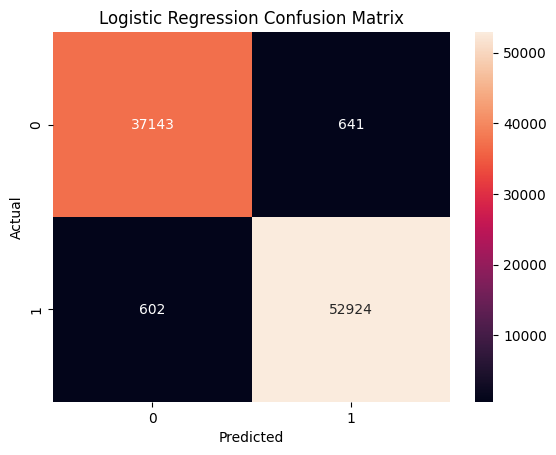

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()